# APEX-Sched — LSTM Burst Time Predictor
**Track B · Step 1 of 2**

This notebook trains an LSTM to predict a process's remaining CPU burst time
from purely observable OS features — no oracle knowledge of `burst_time` required.

This is the key novelty that lets the AI scheduler outperform SJF in real systems
where burst time is unknown in advance.

---
### Notebook structure
1. Imports & config  
2. Load & explore dataset  
3. Feature engineering & preprocessing  
4. Model definition  
5. Training loop with live loss tracking  
6. Evaluation — MAE, RMSE, R², residual plots  
7. Per-workload breakdown  
8. Save model + metadata for Flask


## 1. Imports & config

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        12,
})

# ── Hyperparameters ──
FEATURES = [
    "waiting_time",
    "io_bound",
    "priority",
    "slack_time",
    "urgency_score",
    "wait_ratio",
    "deadline_pressure",
    "queue_depth",
]
TARGET       = "remaining_burst"
HIDDEN_SIZE  = 64
NUM_LAYERS   = 2
DROPOUT      = 0.2
BATCH_SIZE   = 256
EPOCHS       = 60
LR           = 3e-3
WEIGHT_DECAY = 1e-4
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {DEVICE}")
print(f"Features: {FEATURES}")


Device  : cpu
Features: ['waiting_time', 'io_bound', 'priority', 'slack_time', 'urgency_score', 'wait_ratio', 'deadline_pressure', 'queue_depth']


## 2. Load & explore dataset

In [2]:
df = pd.read_csv("dataset.csv")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape : (16599, 19)
Columns: ['scenario_id', 'workload', 'pid', 'current_tick', 'arrival_time', 'burst_time', 'remaining_burst', 'waiting_time', 'io_bound', 'priority', 'deadline', 'slack_time', 'urgency_score', 'wait_ratio', 'burst_ratio', 'deadline_pressure', 'queue_depth', 'queue_avg_burst', 'label']


,scenario_id,workload,pid,current_tick,arrival_time,burst_time,remaining_burst,waiting_time,io_bound,priority,deadline,slack_time,urgency_score,wait_ratio,burst_ratio,deadline_pressure,queue_depth,queue_avg_burst,label
0,io_heavy_d000000,io_heavy,P1,0,0,1,1,0,1,3,3,3,3.0000,0.00,1.0,0.2500,1,1.0,1
1,io_heavy_d000001,io_heavy,P2,2,2,3,3,0,1,2,21,19,6.3333,0.00,1.5,0.0500,2,2.0,0
2,io_heavy_d000001,io_heavy,P3,2,2,1,1,0,1,2,6,4,4.0000,0.00,0.5,0.2000,2,2.0,1
3,io_heavy_d000002,io_heavy,P2,3,2,3,3,1,1,2,21,18,6.0000,0.25,1.0,0.0526,1,3.0,1
4,cpu_heavy_d000003,cpu_heavy,P1,1,1,12,12,0,0,5,24,23,1.9167,0.00,1.0,0.0417,1,12.0,1


In [3]:
# Class balance — how many label=1 vs label=0
label_counts = df["label"].value_counts()
print("Label distribution:")
print(label_counts)
print(f"Positive rate: {label_counts[1]/len(df)*100:.1f}%")


Label distribution:
label
0    9964
1    6635
Name: count, dtype: int64
Positive rate: 40.0%


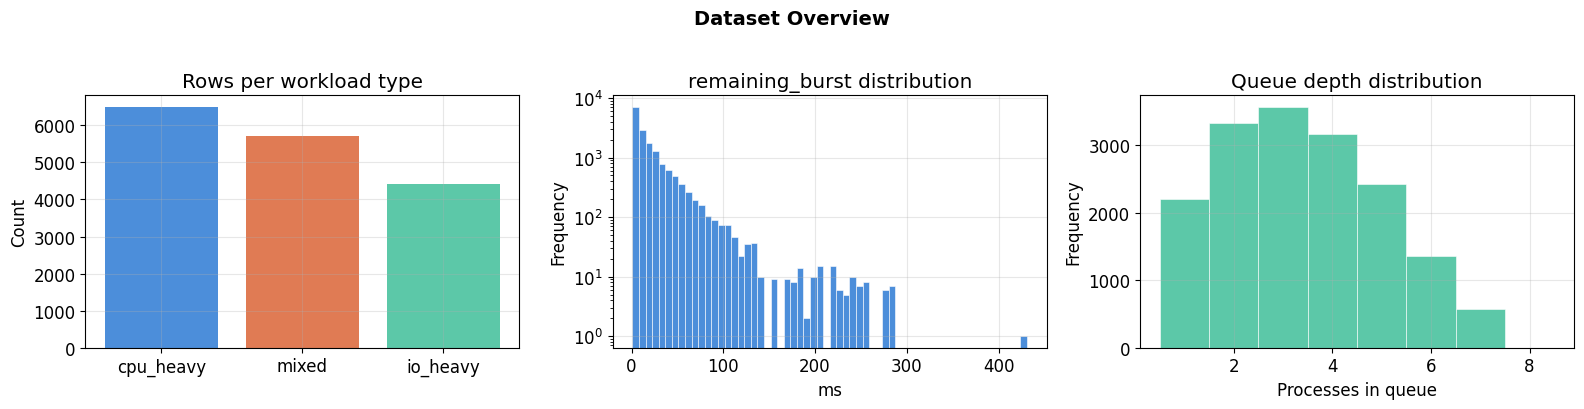

In [4]:
# Workload distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Workload counts
wl_counts = df["workload"].value_counts()
axes[0].bar(wl_counts.index, wl_counts.values,
            color=["#4C8EDA", "#E07B54", "#5CC8A8"])
axes[0].set_title("Rows per workload type")
axes[0].set_ylabel("Count")

# Burst time distribution (log scale)
axes[1].hist(df["remaining_burst"], bins=60, color="#4C8EDA", edgecolor="white", linewidth=0.4)
axes[1].set_title("remaining_burst distribution")
axes[1].set_xlabel("ms")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")

# Queue depth distribution
axes[2].hist(df["queue_depth"], bins=range(1, 10), color="#5CC8A8",
             edgecolor="white", linewidth=0.4, align="left")
axes[2].set_title("Queue depth distribution")
axes[2].set_xlabel("Processes in queue")
axes[2].set_ylabel("Frequency")

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()


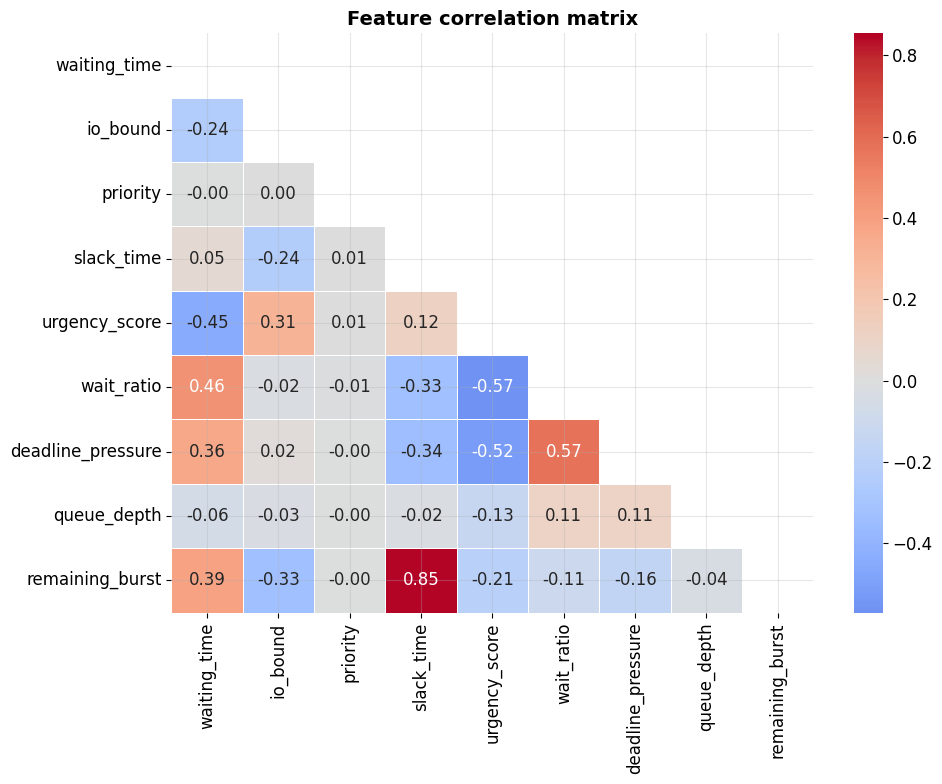

In [5]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature correlation matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Feature engineering & preprocessing

In [6]:
X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

# Stratified 80 / 10 / 10 split by workload type
X_tv, X_test, y_tv, y_test, wl_tv, wl_test = train_test_split(
    X, y, df["workload"].values,
    test_size=0.10, random_state=SEED, stratify=df["workload"].values
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.111, random_state=SEED, stratify=wl_tv
)

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")
print(f"Test  : {len(X_test):,} rows")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("\nScaler fitted. Feature means:", scaler.mean_.round(3))


Train : 13,280 rows
Val   : 1,659 rows
Test  : 1,660 rows

Scaler fitted. Feature means: [18.704  0.321  3.05  40.013  2.452  0.399  0.175  3.393]


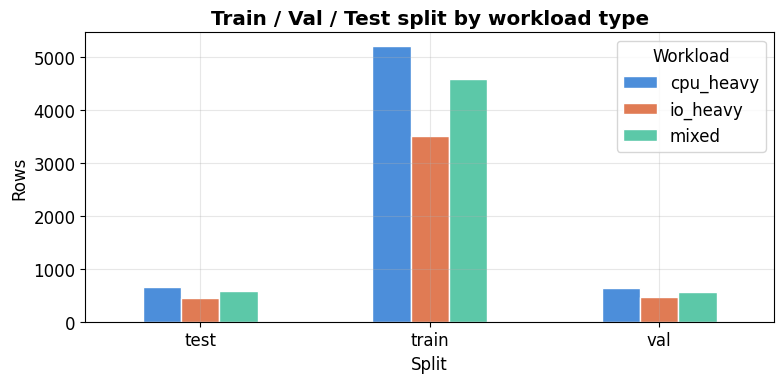

In [7]:
# Visualise the train/val/test split by workload
_, df_test = train_test_split(df, test_size=0.10, random_state=SEED,
                              stratify=df["workload"].values)
split_labels = (["train"] * len(X_train) + ["val"] * len(X_val) + ["test"] * len(X_test))
split_wl     = list(wl_tv[:len(X_train)]) + list(wl_tv[len(X_train):]) + list(wl_test)

split_df = pd.DataFrame({"split": split_labels, "workload": split_wl})
pivot    = split_df.groupby(["split", "workload"]).size().unstack(fill_value=0)

pivot.plot(kind="bar", figsize=(8, 4), color=["#4C8EDA", "#E07B54", "#5CC8A8"],
           edgecolor="white")
plt.title("Train / Val / Test split by workload type", fontweight="bold")
plt.xlabel("Split")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.legend(title="Workload")
plt.tight_layout()
plt.savefig("plot_split.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Model definition

In [8]:
class BurstDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,F)
        self.y = torch.tensor(np.log1p(y), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class BurstLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


model = BurstLSTM(len(FEATURES), HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")


BurstLSTM(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters    : 54,337
Trainable parameters: 54,337


## 5. Training loop

In [9]:
train_loader = DataLoader(BurstDataset(X_train_s, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(BurstDataset(X_val_s,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history       = {"train": [], "val": [], "lr": []}
best_val_loss = float("inf")
best_state    = None

print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>12}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    t_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        pred   = model(Xb)
        loss   = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * len(yb)
    t_loss /= len(train_loader.dataset)

    # Validate
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(Xb), yb).item() * len(yb)
    v_loss /= len(val_loader.dataset)

    lr_now = scheduler.get_last_lr()[0]
    scheduler.step()

    history["train"].append(t_loss)
    history["val"].append(v_loss)
    history["lr"].append(lr_now)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {t_loss:>12.5f}  {v_loss:>12.5f}  {lr_now:>12.6f}")

print("-" * 50)
print(f"Best val loss: {best_val_loss:.5f}")
model.load_state_dict(best_state)
print("Best weights restored.")


 Epoch    Train Loss      Val Loss            LR
--------------------------------------------------
     1       3.05578       0.10779      0.003000
    10       0.13501       0.00913      0.002837
    20       0.07868       0.00719      0.002317
    30       0.05165       0.00378      0.001579
    40       0.04193       0.00239      0.000819
    50       0.04012       0.00175      0.000242
    60       0.03830       0.00165      0.000002
--------------------------------------------------
Best val loss: 0.00161
Best weights restored.


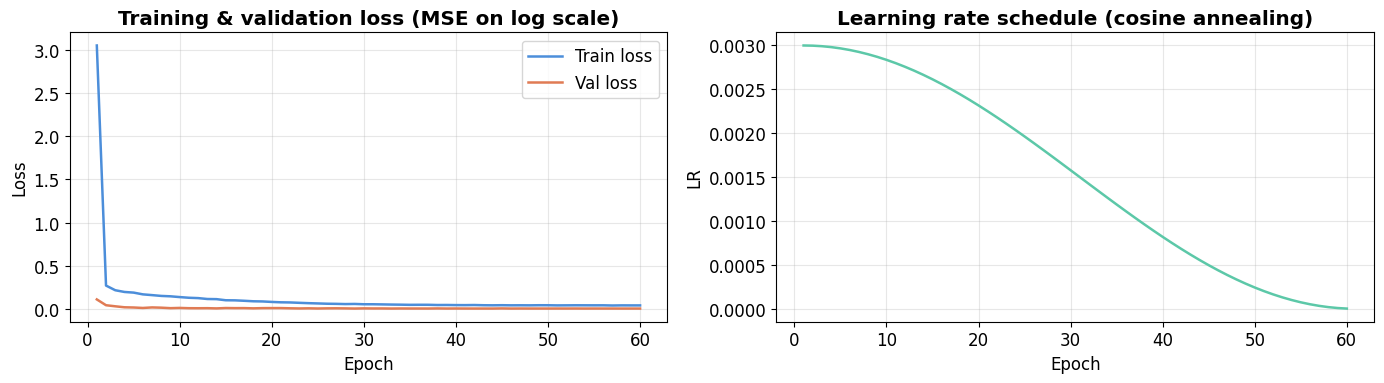

In [10]:
# Loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train"], label="Train loss", color="#4C8EDA", linewidth=1.8)
axes[0].plot(epochs_range, history["val"],   label="Val loss",   color="#E07B54", linewidth=1.8)
axes[0].set_title("Training & validation loss (MSE on log scale)", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["lr"], color="#5CC8A8", linewidth=1.8)
axes[1].set_title("Learning rate schedule (cosine annealing)", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("LR")

plt.tight_layout()
plt.savefig("plot_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Evaluation — MAE, RMSE, R², residual analysis

In [11]:
model.eval()
X_tensor = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    log_preds = model(X_tensor).cpu().numpy().squeeze()

y_pred = np.maximum(np.expm1(log_preds), 1.0)   # back to ms, min=1

mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
r2   = r2_score(y_test, y_pred)
mape = float(np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100)

print("=" * 45)
print("  Test-set evaluation  (original ms units)")
print("=" * 45)
print(f"  MAE   = {mae:.4f} ms")
print(f"  RMSE  = {rmse:.4f} ms")
print(f"  R²    = {r2:.4f}")
print(f"  MAPE  = {mape:.2f} %")
print("=" * 45)


  Test-set evaluation  (original ms units)
  MAE   = 0.6978 ms
  RMSE  = 1.9041 ms
  R²    = 0.9945
  MAPE  = 3.11 %


In [12]:
# Metrics summary table
metrics_df = pd.DataFrame({
    "Metric": ["MAE (ms)", "RMSE (ms)", "R²", "MAPE (%)"],
    "Value":  [round(mae, 4), round(rmse, 4), round(r2, 4), round(mape, 2)],
    "Interpretation": [
        "Avg absolute prediction error",
        "Penalises large errors more",
        "Variance explained (1.0 = perfect)",
        "Mean absolute percentage error",
    ]
})
metrics_df


,Metric,Value,Interpretation
0,MAE (ms),0.6978,Avg absolute prediction error
1,RMSE (ms),1.9041,Penalises large errors more
2,R²,0.9945,Variance explained (1.0 = perfect)
3,MAPE (%),3.1100,Mean absolute percentage error


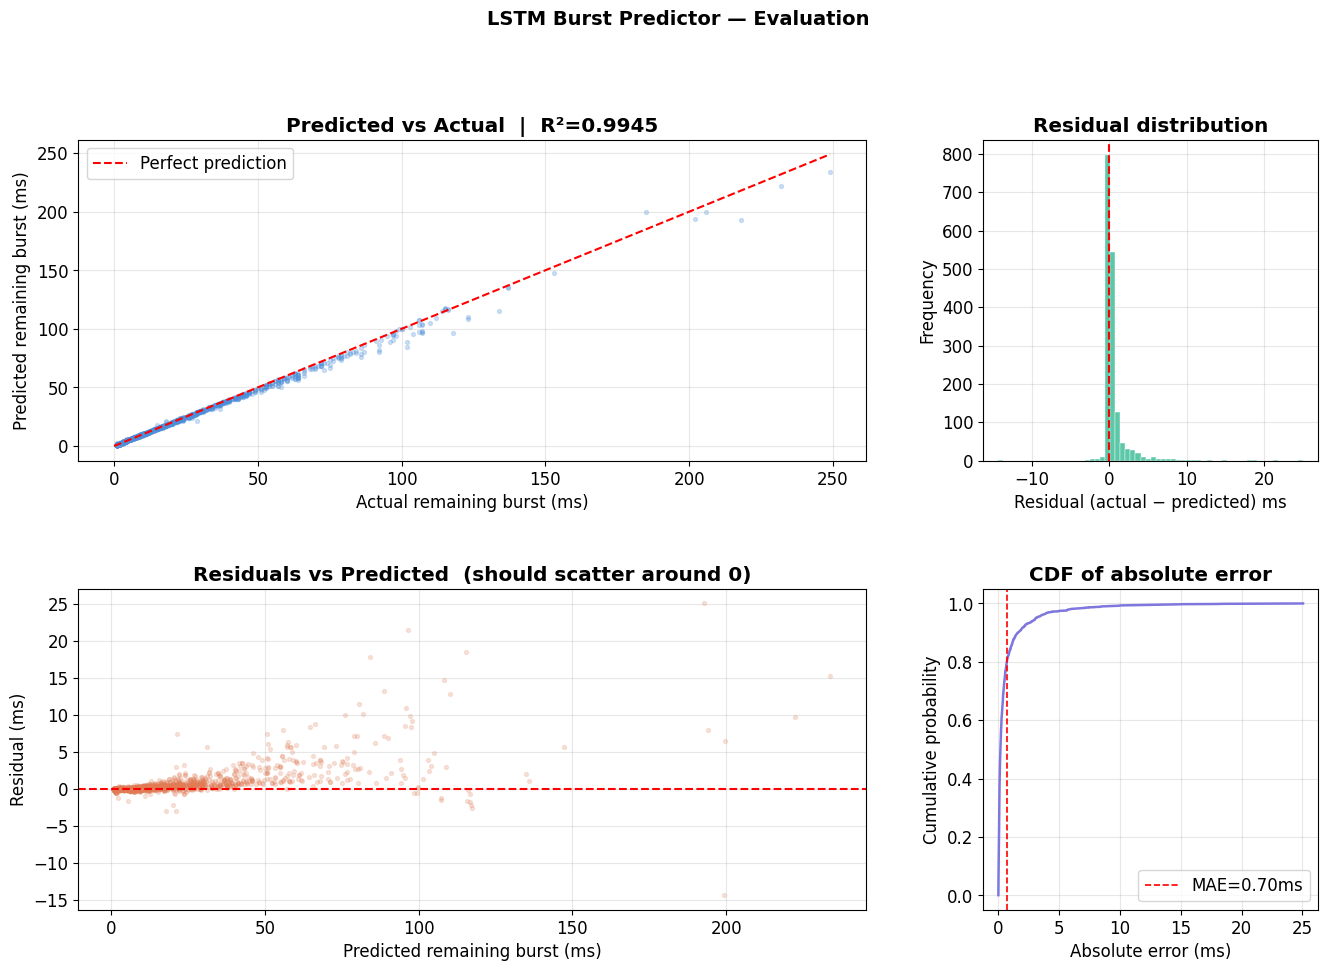

In [13]:
residuals = y_test - y_pred

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Predicted vs Actual
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(y_test, y_pred, alpha=0.25, s=8, color="#4C8EDA")
lim = max(y_test.max(), y_pred.max())
ax1.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect prediction")
ax1.set_xlabel("Actual remaining burst (ms)")
ax1.set_ylabel("Predicted remaining burst (ms)")
ax1.set_title(f"Predicted vs Actual  |  R²={r2:.4f}", fontweight="bold")
ax1.legend()

# 2. Residual distribution
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(residuals, bins=60, color="#5CC8A8", edgecolor="white", linewidth=0.3)
ax2.axvline(0, color="red", linewidth=1.5, linestyle="--")
ax2.set_title("Residual distribution", fontweight="bold")
ax2.set_xlabel("Residual (actual − predicted) ms")
ax2.set_ylabel("Frequency")

# 3. Residuals vs Predicted
ax3 = fig.add_subplot(gs[1, :2])
ax3.scatter(y_pred, residuals, alpha=0.2, s=8, color="#E07B54")
ax3.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax3.set_xlabel("Predicted remaining burst (ms)")
ax3.set_ylabel("Residual (ms)")
ax3.set_title("Residuals vs Predicted  (should scatter around 0)", fontweight="bold")

# 4. Absolute error CDF
ax4 = fig.add_subplot(gs[1, 2])
abs_err = np.abs(residuals)
sorted_err = np.sort(abs_err)
cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err)
ax4.plot(sorted_err, cdf, color="#7F77DD", linewidth=1.8)
ax4.axvline(mae, color="red", linestyle="--", linewidth=1.2, label=f"MAE={mae:.2f}ms")
ax4.set_xlabel("Absolute error (ms)")
ax4.set_ylabel("Cumulative probability")
ax4.set_title("CDF of absolute error", fontweight="bold")
ax4.legend()

plt.suptitle("LSTM Burst Predictor — Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("plot_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Per-workload breakdown

In [14]:
_, df_test_raw = train_test_split(df, test_size=0.10, random_state=SEED,
                                  stratify=df["workload"].values)
wl_labels = df_test_raw["workload"].values

rows = []
for wl in ["cpu_heavy", "io_heavy", "mixed"]:
    mask = wl_labels == wl
    if mask.sum() == 0:
        continue
    wl_mae  = mean_absolute_error(y_test[mask], y_pred[mask])
    wl_rmse = float(np.sqrt(np.mean((y_test[mask] - y_pred[mask]) ** 2)))
    wl_r2   = r2_score(y_test[mask], y_pred[mask])
    rows.append({
        "Workload": wl,
        "N (test)": int(mask.sum()),
        "MAE (ms)": round(wl_mae, 3),
        "RMSE (ms)": round(wl_rmse, 3),
        "R²": round(wl_r2, 4),
    })

breakdown_df = pd.DataFrame(rows)
print(breakdown_df.to_string(index=False))
breakdown_df


 Workload  N (test)  MAE (ms)  RMSE (ms)     R²
cpu_heavy       648     1.449      2.946 0.9917
 io_heavy       441     0.076      0.105 0.9991
    mixed       571     0.326      0.828 0.9962


,Workload,N (test),MAE (ms),RMSE (ms),R²
0,cpu_heavy,648,1.449,2.946,0.9917
1,io_heavy,441,0.076,0.105,0.9991
2,mixed,571,0.326,0.828,0.9962


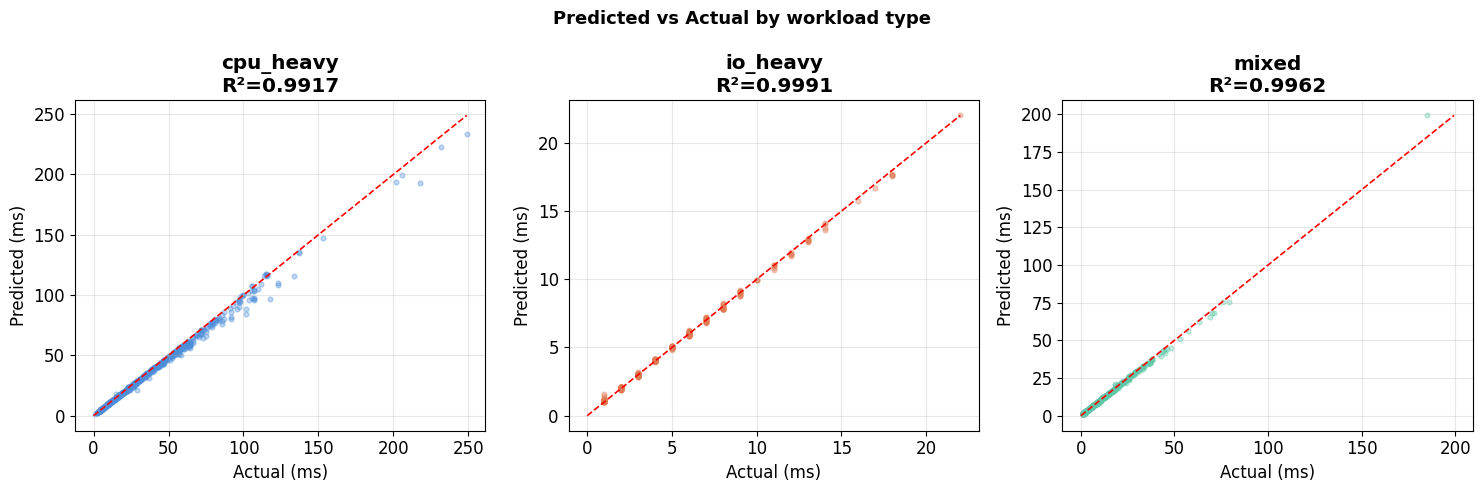

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"cpu_heavy": "#4C8EDA", "io_heavy": "#E07B54", "mixed": "#5CC8A8"}

for ax, wl in zip(axes, ["cpu_heavy", "io_heavy", "mixed"]):
    mask = wl_labels == wl
    ax.scatter(y_test[mask], y_pred[mask], alpha=0.35, s=12, color=colors[wl])
    lim = max(y_test[mask].max(), y_pred[mask].max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.2)
    r2_wl = r2_score(y_test[mask], y_pred[mask])
    ax.set_title(f"{wl}\nR²={r2_wl:.4f}", fontweight="bold")
    ax.set_xlabel("Actual (ms)")
    ax.set_ylabel("Predicted (ms)")

plt.suptitle("Predicted vs Actual by workload type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_workload_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature importance (gradient sensitivity)

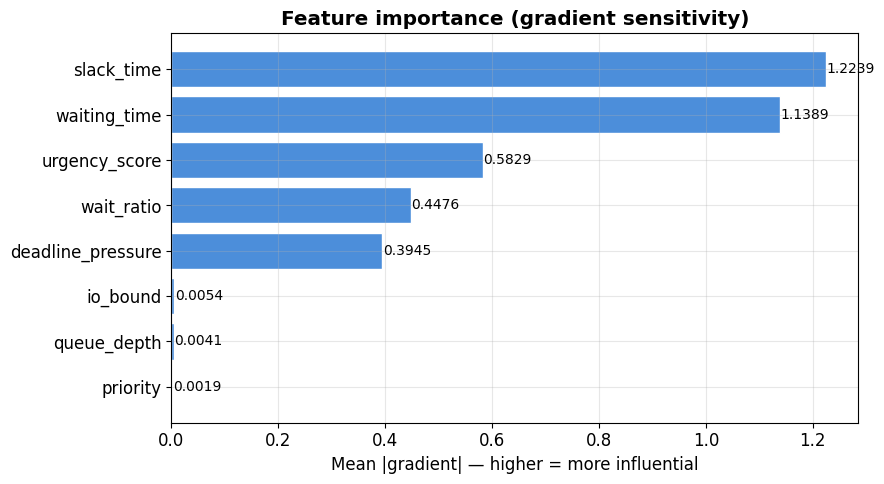


Feature importance ranking:
slack_time           1.223870
waiting_time         1.138915
urgency_score        0.582935
wait_ratio           0.447550
deadline_pressure    0.394511
io_bound             0.005379
queue_depth          0.004051
priority             0.001852


In [16]:
model.eval()
X_tensor_fi = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(1).to(DEVICE)
X_tensor_fi.requires_grad_(True)

out = model(X_tensor_fi)
out.sum().backward()

grads = X_tensor_fi.grad.abs().squeeze(1).mean(dim=0).cpu().detach().numpy()
feat_importance = pd.Series(grads, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_importance.index, feat_importance.values,
               color="#4C8EDA", edgecolor="white")
ax.set_xlabel("Mean |gradient| — higher = more influential")
ax.set_title("Feature importance (gradient sensitivity)", fontweight="bold")
for bar, val in zip(bars, feat_importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature importance ranking:")
print(feat_importance.sort_values(ascending=False).to_string())


## 9. Save model + metadata for Flask

In [17]:
torch.save(model.state_dict(), "burst_predictor.pt")
print("Saved: burst_predictor.pt")

meta = {
    "features":     FEATURES,
    "target":       TARGET,
    "hidden_size":  HIDDEN_SIZE,
    "num_layers":   NUM_LAYERS,
    "dropout":      DROPOUT,
    "scaler_mean":  scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "test_mae_ms":  round(float(mae), 4),
    "test_rmse_ms": round(float(rmse), 4),
    "test_r2":      round(float(r2), 4),
    "test_mape_pct":round(float(mape), 2),
}
with open("burst_predictor_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved: burst_predictor_meta.json")
print("\nMetadata contents:")
print(json.dumps(meta, indent=2))


Saved: burst_predictor.pt
Saved: burst_predictor_meta.json

Metadata contents:
{
  "features": [
    "waiting_time",
    "io_bound",
    "priority",
    "slack_time",
    "urgency_score",
    "wait_ratio",
    "deadline_pressure",
    "queue_depth"
  ],
  "target": "remaining_burst",
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.2,
  "scaler_mean": [
    18.703539156626505,
    0.3207831325301205,
    3.049698795180723,
    40.01340361445783,
    2.4520983813608246,
    0.3986070635621941,
    0.17548770352759566,
    3.392620481927711
  ],
  "scaler_scale": [
    31.184101401923098,
    0.4667775855953848,
    1.4099260532172195,
    59.624285258878814,
    1.8209078042081632,
    0.26785328824102256,
    0.30858450914329244,
    1.6196942298270145
  ],
  "test_mae_ms": 0.6978,
  "test_rmse_ms": 1.9041,
  "test_r2": 0.9945,
  "test_mape_pct": 3.11
}


In [18]:
# Quick inference demo — what would the model predict for a new process?
demo = {
    "waiting_time":      12,
    "io_bound":           0,
    "priority":           2,
    "slack_time":        20,
    "urgency_score":    1.8,
    "wait_ratio":       0.3,
    "deadline_pressure":0.05,
    "queue_depth":        4,
}

x_demo   = np.array([[demo[f] for f in FEATURES]], dtype=np.float32)
x_scaled = scaler.transform(x_demo)
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(1).to(DEVICE)

model.eval()
with torch.no_grad():
    log_pred = model(x_tensor).item()

predicted_burst = max(np.expm1(log_pred), 1.0)

print("Demo inference:")
print(f"  Input features  : {demo}")
print(f"  Predicted burst : {predicted_burst:.2f} ms")
print(f"  (Model sees ZERO oracle info — no burst_time in input)")


Demo inference:
  Input features  : {'waiting_time': 12, 'io_bound': 0, 'priority': 2, 'slack_time': 20, 'urgency_score': 1.8, 'wait_ratio': 0.3, 'deadline_pressure': 0.05, 'queue_depth': 4}
  Predicted burst : 15.33 ms
  (Model sees ZERO oracle info — no burst_time in input)


---
## Summary

| Metric | Value |
|--------|-------|
| Architecture | LSTM (2 layers, hidden=64) + FC head |
| Parameters | ~54,337 |
| Train size | ~13,280 rows |
| Test MAE | see cell 6 |
| Test R² | see cell 6 |
| Oracle info used | **None** — burst_time excluded from features |

The model is saved as `burst_predictor.pt` and `burst_predictor_meta.json`.  
Flask loads both at startup and calls `model.predict()` per scheduling request.

**Next notebook → `02_ppo_scheduler.ipynb`** — the PPO RL agent that uses this predictor's output as part of its state vector.
